In [40]:
import random
import numpy as np
import pandas as pd
import yahooquery as yq

import optuna
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer
from sklearn.metrics import mean_squared_error, root_mean_squared_error

from statsmodels.tsa.stattools import adfuller, grangercausalitytests
from statsmodels.tsa.statespace.sarimax import SARIMAX

from itertools import product
from tqdm.auto import tqdm

import seaborn as sns
import matplotlib.pyplot as plt

# Load & Prep Data

In [41]:
sentiment_df = pd.read_csv("../data/group-project/daily-sentiment-comments.csv").rename(columns={"created_date": "date"})
sentiment_df["date"] = pd.to_datetime(sentiment_df["date"])
sentiment_df.sample(5)

,date,final_score,score
2802,2020-04-25,-0.573687,5.8
4065,2023-10-10,-0.254467,2.0
67,2012-06-28,0.367467,3.4
3598,2022-06-30,-0.559021,3.6
2241,2018-10-12,-0.231694,7.6


In [42]:
# https://www.matteoiacoviello.com/gpr.htm
# GPRD - Daily GPR (Index: 1985:2019=100)
# GPRD_ACT - Daily GPR Acts (Index: 1985:2019=100)
# GPRD_THREAT - Daily GPR Threats (Index: 1985:2019=100)
gpr_df = pd.read_stata("../data/group-project/gpr_daily.dta", columns=["date", "GPRD", "GPRD_ACT", "GPRD_THREAT"])
gpr_df.head()

,date,GPRD,GPRD_ACT,GPRD_THREAT
0,1985-01-01,230.039429,275.197601,153.027985
1,1985-01-02,115.676971,146.772064,87.444572
2,1985-01-03,97.428459,158.937653,29.459934
3,1985-01-04,157.366638,156.882248,157.026352
4,1985-01-05,81.361313,92.698143,77.319405


In [43]:
vix = yq.Ticker("^VIX").history(interval="1d", start="2012-01-01", end="2026-01-01").reset_index()
vix["date"] = pd.to_datetime(vix["date"])
vix = vix.drop(columns=["symbol", "open", "high", "low", "close", "volume"])
vix.head()

,date,adjclose
0,2012-01-03,22.969999
1,2012-01-04,22.219999
2,2012-01-05,21.480000
3,2012-01-06,20.629999
4,2012-01-09,21.070000


In [44]:
# merge vix and sentiment and gpr
df = vix \
    .merge(sentiment_df, on="date", how="left") \
    .merge(gpr_df, on="date", how="left") \
    .dropna()
df = df.sort_values("date").reset_index(drop=True)

# add log return
df["log_return"] = np.log(df["adjclose"]).diff()
df = df.dropna()

# note: this data is unshifted t_adjclose = t_final_score = t_score
df.head()

,date,adjclose,final_score,score,GPRD,GPRD_ACT,GPRD_THREAT,log_return
1,2012-04-17,18.459999,0.000000,3.333333,117.745300,117.382874,97.908905,-0.081126
2,2012-04-19,18.360001,0.000000,2.000000,65.094124,36.052086,90.213005,-0.005432
3,2012-04-23,18.969999,0.178730,2.000000,90.460236,85.887421,78.802452,0.032684
4,2012-04-24,18.100000,-0.077251,2.600000,93.368942,64.752380,114.770996,-0.046947
5,2012-04-25,16.820000,-0.272216,2.800000,83.951027,125.538933,58.173260,-0.073343


# SARIMA

## Prep Data

In [45]:
df_sarima = df.copy()

df_sarima["3w_rolling_mean"] = df_sarima["log_return"].rolling(21, min_periods=21).mean()
df_sarima["6w_rolling_mean"] = df_sarima["log_return"].rolling(42, min_periods=42).mean()
df_sarima["1y_rolling_mean"] = df_sarima["log_return"].rolling(365, min_periods=365).mean()

df_sarima["3w_rolling_std"] = df_sarima["log_return"].rolling(21, min_periods=21).std()
df_sarima["6w_rolling_std"] = df_sarima["log_return"].rolling(42, min_periods=42).std()
df_sarima["1y_rolling_std"] = df_sarima["log_return"].rolling(365, min_periods=365).std()

df_sarima = df_sarima.dropna()

In [46]:
exog_cols = [
    "3w_rolling_mean",
    "6w_rolling_mean",
    "3w_rolling_std",
    "6w_rolling_std",
    "GPRD_THREAT",
    "GPRD_ACT",
    "GPRD",
]

### With TimeSeriesSplit

In [47]:
from sklearn.model_selection import TimeSeriesSplit

In [48]:
X =  df_sarima[exog_cols]
y =  df_sarima["log_return"]

# ARIMA only differences y, not X
# we will have to manually diff X
X_diffed = X.diff().dropna()

# realign with y
X = X_diffed
y = y[1:]

In [49]:
n_splits = 6
test_size = 20 # next 20 trading days
tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)

C:\miniforge3\envs\machine-learning\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\miniforge3\envs\machine-learning\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\miniforge3\envs\machine-learning\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\miniforge3\envs\machine-learning\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
C:\miniforge3\envs\machine-learning\Lib\site-packages\st

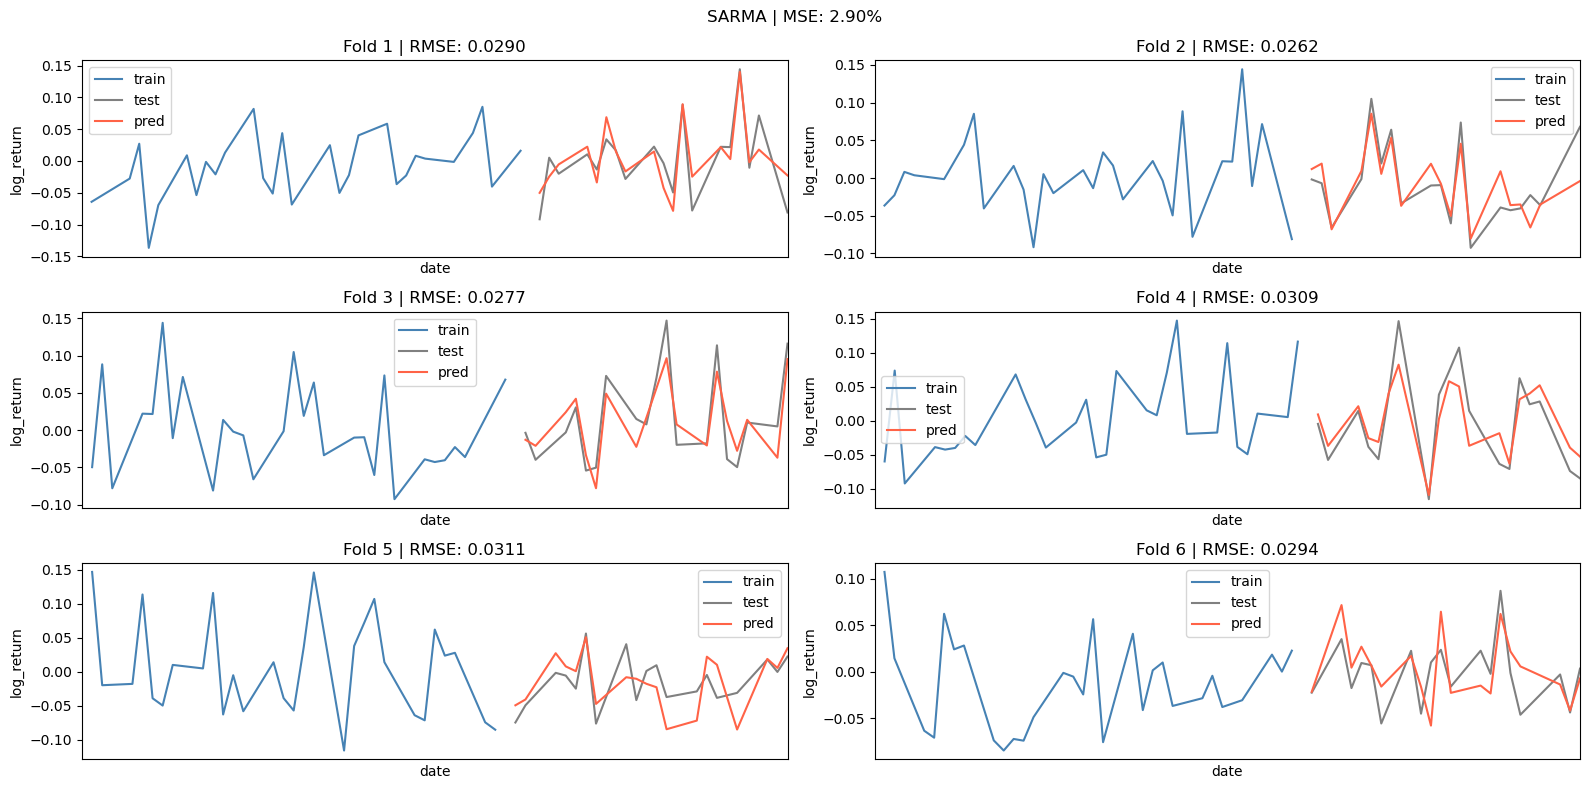

In [50]:
scores = []

fig, axes = plt.subplots(figsize=(16, 8), nrows=3, ncols=2)
axes = axes.flatten()

for fold, (train_idx, test_idx) in enumerate(tscv.split(X)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    # train model and get preds
    model = SARIMAX(y_train,
                exog=X_train,
                order=(7, 0, 2),
                enforce_invertibility=False, enforce_stationarity=False,
                trend='c'
                # seasonal_order=(1, 0, 1, 5)
                )

    fitted = model.fit(disp=False, maxiter=10_000)
    y_preds = fitted.forecast(steps=len(X_test), exog=X_test)

    # plotting
    ax = axes[fold]

    # show last 30 points of training data
    train_show_idx = train_idx[-30:]
    sns.lineplot(x=df_sarima['date'].iloc[train_show_idx], y=y.iloc[train_show_idx],
                  label='train', color='steelblue', ax=ax)

    sns.lineplot(x=df_sarima['date'].iloc[test_idx], y=y_test,
                  label='test', color='grey', ax=ax)

    sns.lineplot(x=df_sarima['date'].iloc[test_idx], y=y_preds,
                  label='pred', color='tomato', ax=ax)

    ax.set_xlim([df_sarima['date'].iloc[train_show_idx[0]], df_sarima['date'].iloc[test_idx[-1]]])
    ax.set_xticks([])
    mse = np.sqrt(mean_squared_error(y_test, y_preds))
    scores.append(mse)
    ax.set_title(f'Fold {fold + 1} | RMSE: {mse:.4f}')
    ax.legend()

plt.suptitle(f"SARMA | MSE: {np.mean(scores):.2%}")
plt.tight_layout()
plt.show()

# ML Forecast

In [108]:
from mlforecast import MLForecast
from mlforecast.lag_transforms import ExpandingMean, RollingMean, SeasonalRollingMean, RollingStd
from mlforecast.target_transforms import Differences, LocalStandardScaler

# models
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [51]:
df.head()

,date,adjclose,final_score,score,GPRD,GPRD_ACT,GPRD_THREAT,log_return
1,2012-04-17,18.459999,0.000000,3.333333,117.745300,117.382874,97.908905,-0.081126
2,2012-04-19,18.360001,0.000000,2.000000,65.094124,36.052086,90.213005,-0.005432
3,2012-04-23,18.969999,0.178730,2.000000,90.460236,85.887421,78.802452,0.032684
4,2012-04-24,18.100000,-0.077251,2.600000,93.368942,64.752380,114.770996,-0.046947
5,2012-04-25,16.820000,-0.272216,2.800000,83.951027,125.538933,58.173260,-0.073343


In [101]:
df_log_return = df.drop(columns=["adjclose", "score"]).rename(columns={"log_return": "y", "date": "ds"})
df_log_return["unique_id"] = "log_return"

# fill missing business days with forward-fill
df_log_return = df_log_return.set_index('ds').asfreq('B', method='ffill').reset_index()

df_log_return.head()

,ds,final_score,GPRD,GPRD_ACT,GPRD_THREAT,y,unique_id
0,2012-04-17,0.00000,117.745300,117.382874,97.908905,-0.081126,log_return
1,2012-04-18,0.00000,117.745300,117.382874,97.908905,-0.081126,log_return
2,2012-04-19,0.00000,65.094124,36.052086,90.213005,-0.005432,log_return
3,2012-04-20,0.00000,65.094124,36.052086,90.213005,-0.005432,log_return
4,2012-04-23,0.17873,90.460236,85.887421,78.802452,0.032684,log_return


In [102]:
n_splits = 6
test_size = 20 # next 20 trading days
tscv = TimeSeriesSplit(n_splits=n_splits, test_size=test_size)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000229 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7905
[LightGBM] [Info] Number of data points in the train set: 2894, number of used features: 31
[LightGBM] [Info] Start training from score -0.001379
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000273 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7905
[LightGBM] [Info] Number of data points in the train set: 2914, number of used features: 31
[LightGBM] [Info] Start training from score -0.001333
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000329 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7905
[LightGBM] [Info] Number of data points in the train set: 2934, number of used features: 31
[LightGBM] [Info] Start trai

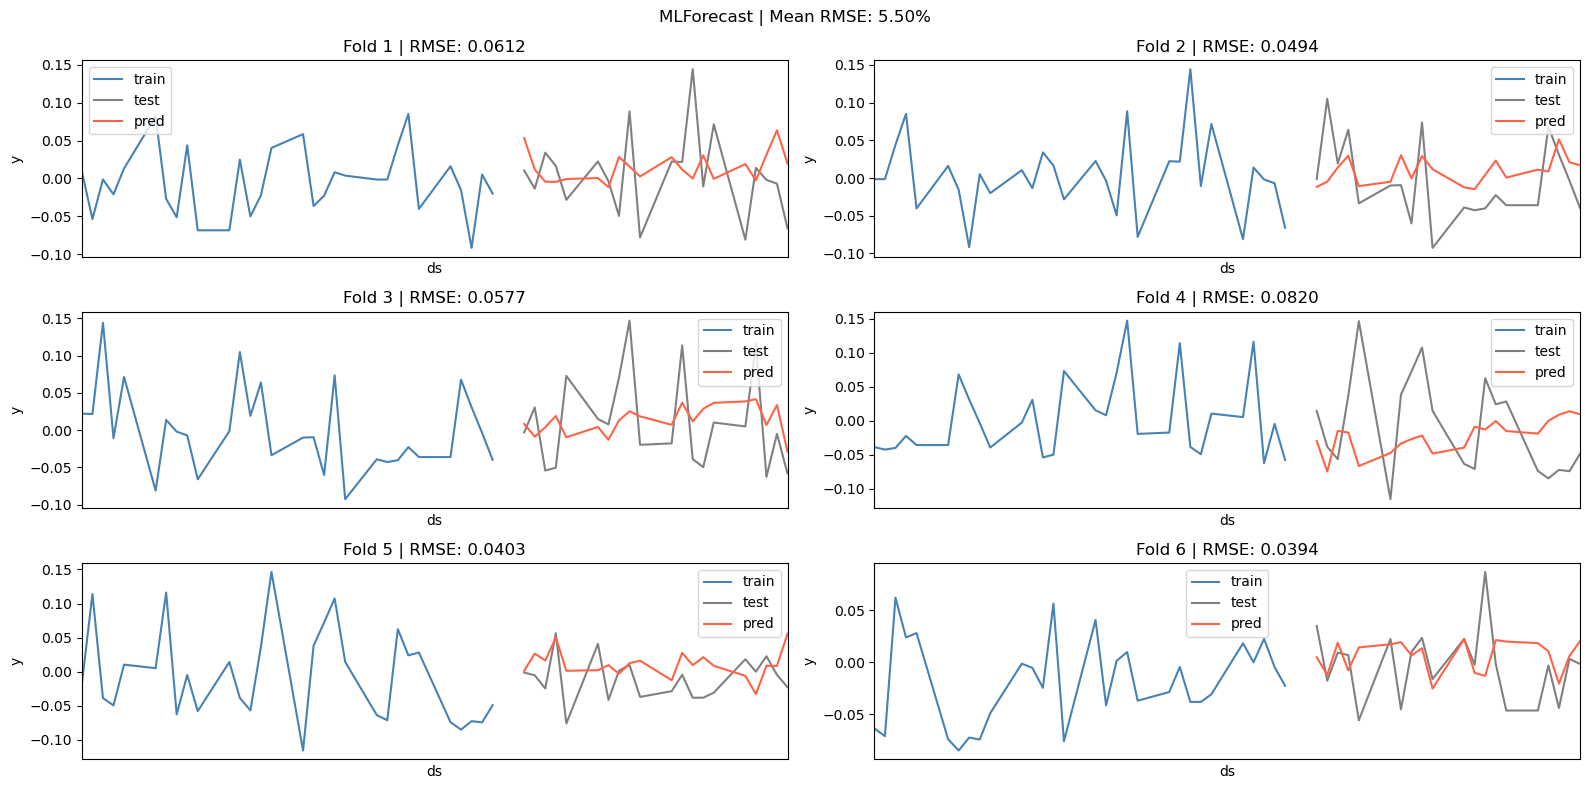

In [110]:
scores = []

fig, axes = plt.subplots(figsize=(16, 8), nrows=3, ncols=2)
axes = axes.flatten()

for fold, (train_idx, test_idx) in enumerate(tscv.split(df_log_return)):
    # Split data
    train_df = df_log_return.iloc[train_idx].copy()
    test_df = df_log_return.iloc[test_idx].copy()

    # Initialize and fit MLForecast
    fcst = MLForecast(
        models=[LGBMRegressor(random_state=42)],
        freq="B",
        lags=[5 * (i+1) for i in range(8)],
        lag_transforms = {
            1:  [ExpandingMean()],
            5:  [RollingMean(5), RollingMean(10), RollingMean(20), RollingStd(5), RollingStd(10), RollingStd(20)],
            15: [RollingMean(5), RollingMean(10), RollingMean(20), RollingStd(5), RollingStd(10), RollingStd(20)],
            20: [RollingMean(5), RollingMean(10), RollingMean(20), RollingStd(5), RollingStd(10), RollingStd(20)],
        }
    )

    fcst.fit(train_df, static_features=[])

    # Get predictions
    h = len(test_idx)

    # Include unique_id and ds along with exogenous features
    X_test = test_df[['unique_id', 'ds', 'final_score', 'GPRD', 'GPRD_ACT', 'GPRD_THREAT']]
    y_preds = fcst.predict(h=h, X_df=X_test)

    # Extract actual predictions (MLForecast returns a dataframe)
    y_pred_values = y_preds['LGBMRegressor'].values
    y_test_values = test_df['y'].values
    y_train_values = train_df['y'].values

    # Plotting
    ax = axes[fold]

    # Show last 30 points of training data
    train_show_idx = train_idx[-30:]
    sns.lineplot(x=df_log_return['ds'].iloc[train_show_idx],
                 y=df_log_return['y'].iloc[train_show_idx],
                 label='train', color='steelblue', ax=ax)

    sns.lineplot(x=df_log_return['ds'].iloc[test_idx],
                 y=y_test_values,
                 label='test', color='grey', ax=ax)

    sns.lineplot(x=df_log_return['ds'].iloc[test_idx],
                 y=y_pred_values,
                 label='pred', color='tomato', ax=ax)

    ax.set_xlim([df_log_return['ds'].iloc[train_show_idx[0]],
                 df_log_return['ds'].iloc[test_idx[-1]]])
    ax.set_xticks([])

    rmse = np.sqrt(mean_squared_error(y_test_values, y_pred_values))
    scores.append(rmse)
    ax.set_title(f'Fold {fold + 1} | RMSE: {rmse:.4f}')
    ax.legend()

plt.suptitle(f"MLForecast | Mean RMSE: {np.mean(scores):.2%}")
plt.tight_layout()
plt.show()